In [1]:
from pathlib import Path
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
# Windows에서는 Malgun Gothic, macOS에서는 AppleGothic, 그 외 환경에서는 NanumGothic을 사용합니다.
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [2]:
profile_path = "../../data/preprocessed/user_profile.csv"
event_path = "../../data/preprocessed/event_log.csv"

user_df = pd.read_csv(profile_path)
event_df = pd.read_csv(event_path)

In [3]:
def check_dataframe(df, name):
    print("=" * 60)
    print(f"{name} 기본 정보")
    print("=" * 60)

    print("\n[데이터 크기]")
    print(f"행: {df.shape[0]:,}개")
    print(f"열: {df.shape[1]:,}개")

    print("\n[컬럼 목록]")
    print(df.columns.tolist())

    print("\n[자료형]")
    print(df.dtypes)

    print("\n[결측치 개수]")
    print(
        df.isna()
        .sum()
        .sort_values(ascending=False)
    )

    print("\n[완전 중복 행]")
    print(df.duplicated().sum())

    print("\n[앞부분 데이터]")
    display(df.head())

In [4]:
check_dataframe(user_df, "사용자 프로필")
check_dataframe(event_df, "이벤트 로그")

사용자 프로필 기본 정보

[데이터 크기]
행: 12,500개
열: 8개

[컬럼 목록]
['User_ID', '가입일자', '가입경로', '기기', '알림수신동의여부', '알림수신동의_변경일자', '가입연월', '활동여부']

[자료형]
User_ID         str
가입일자            str
가입경로            str
기기              str
알림수신동의여부        str
알림수신동의_변경일자     str
가입연월            str
활동여부           bool
dtype: object

[결측치 개수]
알림수신동의_변경일자    10524
User_ID            0
가입경로               0
가입일자               0
기기                 0
알림수신동의여부           0
가입연월               0
활동여부               0
dtype: int64

[완전 중복 행]
0

[앞부분 데이터]


,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자,가입연월,활동여부
0,U0000001,2025-01-25,오가닉,iOS,동의,NaN,2025-01,True
1,U0000002,2025-05-06,오가닉,iOS,미동의,2025-05-24,2025-05,True
2,U0000003,2025-05-14,오가닉,iOS,미동의,NaN,2025-05,True
3,U0000004,2025-02-23,퍼포먼스광고,Android,동의,NaN,2025-02,True
4,U0000005,2025-02-18,퍼포먼스광고,Android,동의,NaN,2025-02,True


이벤트 로그 기본 정보

[데이터 크기]
행: 1,757,262개
열: 17개

[컬럼 목록]
['User_ID', 'Event_Time', 'Event_Type', 'Session_ID', '알림_유형', '이벤트유형_결측여부', '세션ID_결측여부', '이벤트일자', '이벤트연월', '가입일자', '가입경로', '기기', '알림수신동의여부', '가입연월', '가입후경과일', '사용자활동여부', '알림수신이벤트여부']

[자료형]
User_ID         str
Event_Time      str
Event_Type      str
Session_ID      str
알림_유형           str
이벤트유형_결측여부     bool
세션ID_결측여부      bool
이벤트일자           str
이벤트연월           str
가입일자            str
가입경로            str
기기              str
알림수신동의여부        str
가입연월            str
가입후경과일        int64
사용자활동여부        bool
알림수신이벤트여부      bool
dtype: object

[결측치 개수]
Session_ID    241502
가입경로           19311
기기             18023
User_ID            0
Event_Time         0
이벤트유형_결측여부         0
세션ID_결측여부          0
Event_Type         0
알림_유형              0
이벤트연월              0
이벤트일자              0
가입일자               0
알림수신동의여부           0
가입연월               0
가입후경과일             0
사용자활동여부            0
알림수신이벤트여부          0
dtype: int64

[완전 중복 행]
0

[앞부분 데이터

,User_ID,Event_Time,Event_Type,Session_ID,알림_유형,이벤트유형_결측여부,세션ID_결측여부,이벤트일자,이벤트연월,가입일자,가입경로,기기,알림수신동의여부,가입연월,가입후경과일,사용자활동여부,알림수신이벤트여부
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,해당없음,False,False,2025-01-25,2025-01,2025-01-25,오가닉,iOS,동의,2025-01,0,True,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,해당없음,False,False,2025-01-25,2025-01,2025-01-25,오가닉,iOS,동의,2025-01,0,True,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,해당없음,False,False,2025-01-25,2025-01,2025-01-25,오가닉,iOS,동의,2025-01,0,True,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,해당없음,False,False,2025-01-25,2025-01,2025-01-25,오가닉,iOS,동의,2025-01,0,True,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,False,True,2025-01-25,2025-01,2025-01-25,오가닉,iOS,동의,2025-01,0,False,True


In [5]:
print("가입일 최소값:", user_df["가입일자"].min())
print("가입일 최대값:", user_df["가입일자"].max())

print("이벤트 발생 최소값:", event_df["Event_Time"].min())
print("이벤트 발생 최대값:", event_df["Event_Time"].max())

가입일 최소값: 2025-01-01
가입일 최대값: 2025-05-26
이벤트 발생 최소값: 2025-01-01 07:00:07
이벤트 발생 최대값: 2025-06-30 22:59:51


기간의 범위 확인을 위해 가입일의 최대 최소값과 
이벤트 발생의 최대 최소값을 구함

가입일의 최대값은 5월 26일로 확인

이벤트 발생의 최대값은 6월 30일로 확인됨

# 전체 사용자와  이벤트 규모 확인

In [6]:
전체_가입자수 = user_df["User_ID"].nunique()
이벤트_사용자수 = event_df["User_ID"].nunique()
전체_이벤트수 = len(event_df)

print(f"전체 가입자 수: {전체_가입자수:,}명")
print(f"이벤트가 존재하는 사용자 수: {이벤트_사용자수:,}명")
print(f"전체 이벤트 수: {전체_이벤트수:,}건")

전체 가입자 수: 12,500명
이벤트가 존재하는 사용자 수: 12,453명
전체 이벤트 수: 1,757,262건


# 이벤트가 하나도 없는 사용자의 수 확인

In [7]:
이벤트_사용자목록 = event_df["User_ID"].unique()

user_df["이벤트존재여부"] = (
    user_df["User_ID"]
    .isin(이벤트_사용자목록)
)

print(
    user_df["이벤트존재여부"]
    .value_counts()
)

이벤트존재여부
True     12453
False       47
Name: count, dtype: int64


In [8]:
print(
    user_df["이벤트존재여부"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

이벤트존재여부
True     99.62
False     0.38
Name: proportion, dtype: float64


47명은 사용 기록이 아에 없는 그룹

가입 직후 바로 이탈했던가

온보딩을 안했던가

가입만 하고 앱 사용을 안했을 가능성 있음


그럼 일별 가입자 추이를 한번 봐보자

# 일별 가입자 추이

In [9]:
일별_가입자 = (
    user_df
    .groupby("가입일자")["User_ID"]
    .nunique()
    .reset_index(name="가입자수")
)


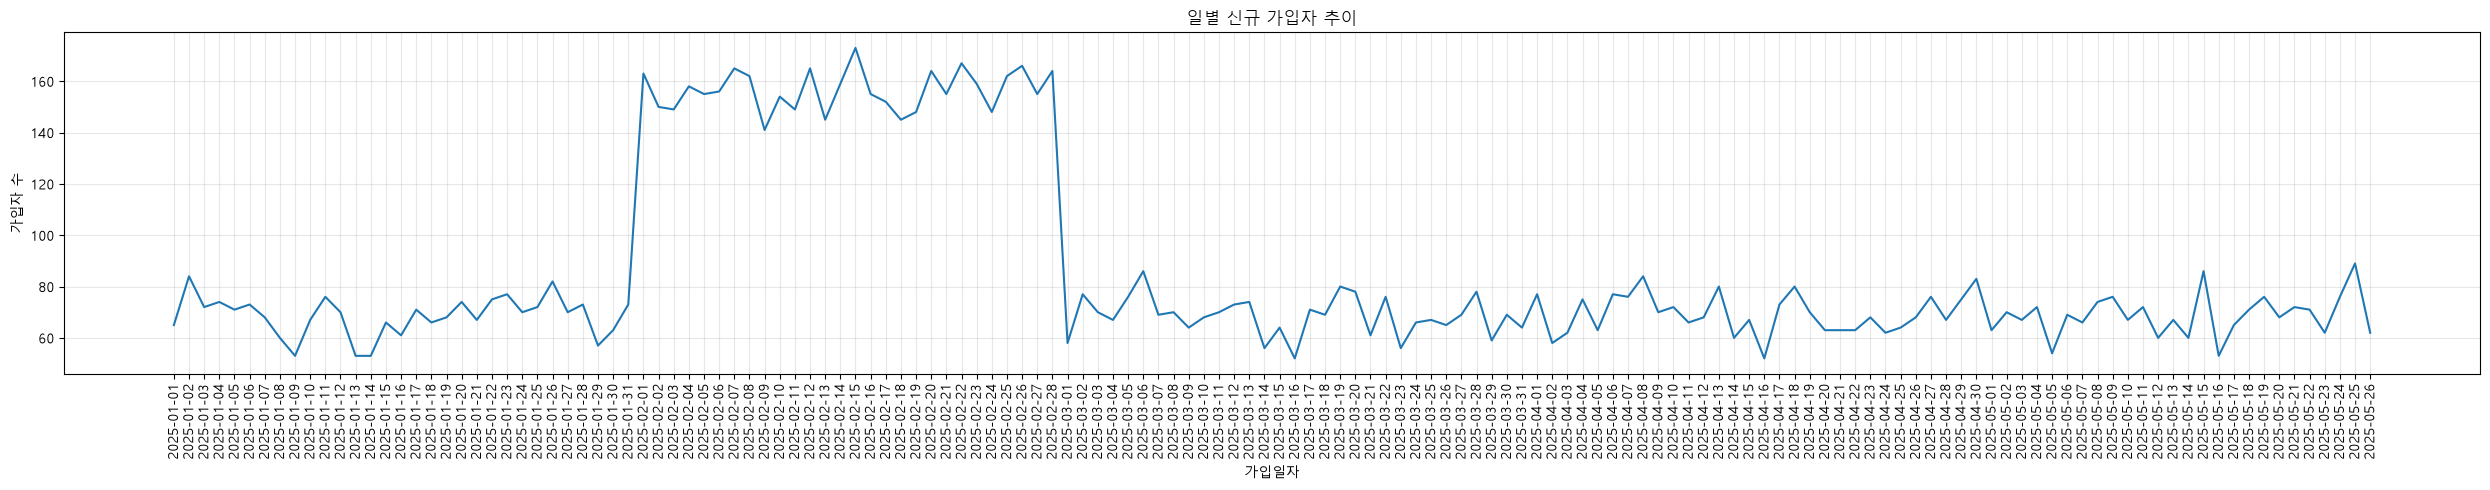

In [10]:
plt.figure(figsize=(25, 5))

plt.plot(
    일별_가입자["가입일자"],
    일별_가입자["가입자수"]
)

plt.title("일별 신규 가입자 추이")
plt.xlabel("가입일자")
plt.ylabel("가입자 수")
plt.xticks(rotation=90)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

그럼 월별가입자는?


In [11]:
월별_가입자 = (
    user_df
    .groupby('가입연월')["User_ID"]
    .nunique()
    .reset_index(name='가입자수')
)

print(월별_가입자.head())

      가입연월  가입자수
0  2025-01  2124
1  2025-02  4384
2  2025-03  2122
3  2025-04  2082
4  2025-05  1788


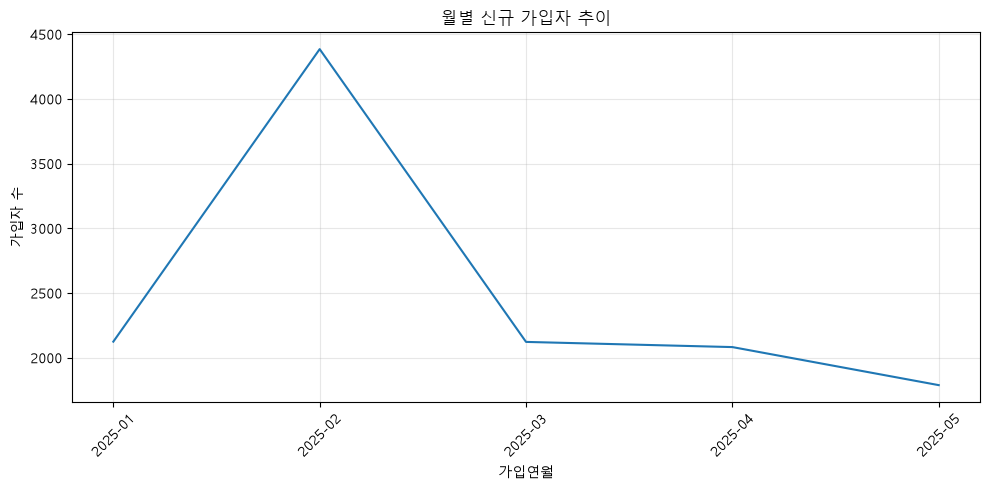

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    월별_가입자["가입연월"],
    월별_가입자["가입자수"]
)

plt.title("월별 신규 가입자 추이")
plt.xlabel("가입연월")
plt.ylabel("가입자 수")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

의견

2월달에 가입자수가 확 늘었다 조금씩 감소하는 추세를 보임

왜??

2월달에 홍보로 인해 앱 자체의 인지도가 확 올랐을 가능성이 있음

일단 기억하고 이후 고호스트 리텐션이랑 같이 확인해보자

# 가입 경로분포

In [ ]:
가입경로_분포 = (
    user_df['가입경로']
    .value_counts(dropna=True)
    .reset_index()
)

In [14]:
가입경로_분포.columns = ['가입경로', '가입자수']

In [ ]:
가입경로_분포['비율'] =(
    가입경로_분포['가입자수'] / 가입경로_분포['가입자수'].sum() * 100
).round(2)

print(가입경로_분포)

print("-"*50)

가입경로_월별분포 = user_df.groupby(['가입연월', '가입경로']).size().unstack(fill_value=0)

가입경로_월별분포['오가닉_비율'] = (
    가입경로_월별분포['오가닉'] / 가입경로_월별분포.sum(axis=1) * 100
).round(1)
print(가입경로_월별분포.head())

     가입경로  가입자수     비율
0  퍼포먼스광고  6852  54.82
1     오가닉  5511  44.09
2    알수없음   137   1.10
--------------------------------------------------
가입경로     알수없음   오가닉  퍼포먼스광고  오가닉_비율
가입연월                               
2025-01    24   966    1134    45.5
2025-02    51  1943    2390    44.3
2025-03    14   904    1204    42.6
2025-04    24   916    1142    44.0
2025-05    24   782     982    43.7


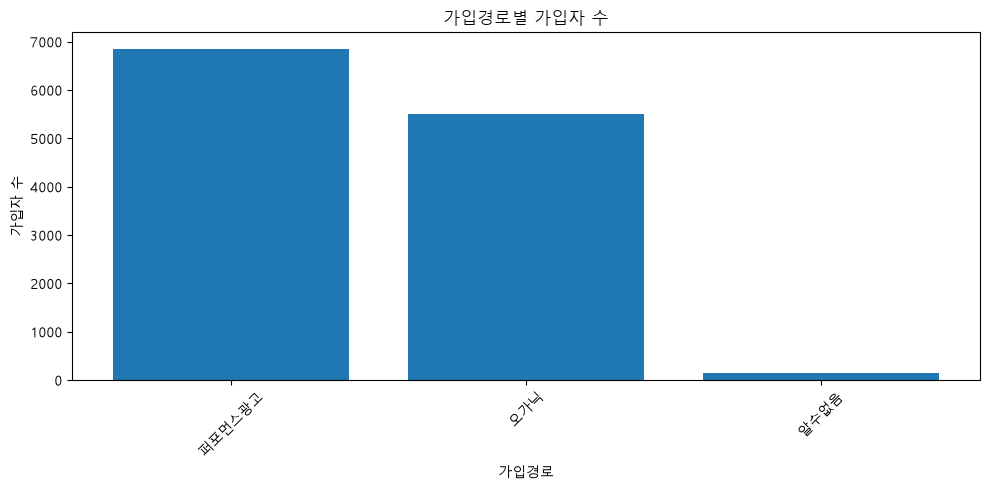

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    가입경로_분포["가입경로"],
    가입경로_분포["가입자수"]
)

plt.title("가입경로별 가입자 수")
plt.xlabel("가입경로")
plt.ylabel("가입자 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

가입경로의 연월 분포는 변화가 없는데 

# 기기 분포 확인   

In [ ]:
기기_분포 = (
    user_df["기기"]
    .value_counts(dropna=False)
    .reset_index()
)

기기_분포.columns = [
    "기기",
    "가입자수"
]

기기_분포["비율"] = (
    기기_분포["가입자수"]
    / 기기_분포["가입자수"].sum()
    * 100
).round(2)

기기_분포

,기기,가입자수,비율
0,iOS,7175,57.40
1,Android,5204,41.63
2,알수없음,121,0.97


In [ ]:
가입기기_월별분포 = user_df.groupby(['가입연월', '기기']).size().unstack(fill_value=0)

가입기기_월별분포['iOS_비율'] = (
    가입기기_월별분포['iOS'] / 가입기기_월별분포.sum(axis=1) * 100
).round(1)
가입기기_월별분포.head()

기기       Android   iOS  알수없음  iOS_비율
가입연월                                
2025-01      847  1256    21    59.1
2025-02     1827  2517    40    57.4
2025-03      872  1228    22    57.9
2025-04      902  1154    26    55.4
2025-05      756  1020    12    57.0


기기별 사용자수 분포를 확인했다
월별로 가입 기기의 차이는 크지 않다

이걸로 추추에 기기별 리텐션 차이가 크다면 기기의 문제로 안한
오류를 의심해볼 수 있음

# 알람수신동의 분포 확인

In [ ]:
알림동의_분포 = (
    user_df["알림수신동의여부"]
    .value_counts(dropna=False)
    .reset_index()
)

알림동의_분포.columns = [
    "알림수신동의여부",
    "사용자수"
]

알림동의_분포["비율"] = (
    알림동의_분포["사용자수"]
    / 알림동의_분포["사용자수"].sum()
    * 100
).round(2)

알림동의_분포

,알림수신동의여부,사용자수,비율
0,동의,7984,63.87
1,미동의,4400,35.20
2,알수없음,116,0.93


In [36]:
수신동의_월별분포 = user_df.groupby(['가입연월', '알림수신동의여부']).size().unstack(fill_value=0)

수신동의_월별분포['동의비율'] = (
    수신동의_월별분포['동의'] / 수신동의_월별분포.sum(axis=1) * 100
).round(1)

수신동의_월별분포.head()

알림수신동의여부,동의,미동의,알수없음,동의비율
가입연월,,,,
2025-01,1330,774,20,62.6
2025-02,2848,1495,41,65.0
2025-03,1304,798,20,61.5
2025-04,1348,715,19,64.7
2025-05,1154,618,16,64.5
